# Modeling with Pyomo

This page is [adapted from our process control class](https://github.com/ndcbe/controls/blob/main/notebooks/06.02-Simulation-and-Open-Loop-Optimal-Control.ipynb) at Notre Dame; it was developed by Prof. Jeff Kantor.

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/IDAES/idaes-pse/main/scripts/colab_helper.py"
    import colab_helper

    colab_helper.install_idaes()
    colab_helper.install_ipopt()

# Set plotting defaults
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('lines', linewidth=3)

In this notebook, we will review Pyomo syntax solving optimization problems with our [TCLab model](./tclab_model.ipynb).

Let's start by defining some model coefficients:

In [2]:
# parameters
alpha = 0.00016  # watts / (units P * percent U1)
P = 200  # P units
Ua = 0.050  # heat transfer coefficient from heater to environment
CpH = 2.2  # heat capacity of the heater (J/deg C)
CpS = 1.9  # heat capacity of the sensor (J/deg C)
Ub = 0.021  # heat transfer coefficient from heater to sensor
Tamb = 21.0  # ambient temperature

## Simulate a Step Test (ramp)

We will start by **simulating** our TCLab model. In other words, we will solve the following optimization problem with zero degrees of freedom:

\begin{align*}
\max{}~~ & 0 \\
\mathrm{s.t.}~~ & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t) \\
 & C_p^S \frac{dT_S}{dt} = - U_b (T_S - T_H) \\
 & T_H(t_0) = T_{amb} \\
 & T_S(t_0) = T_{amb} \\
 & u(t) = u_{ramp} = 50\%, \quad \forall t \in [t_0, t_f]
\end{align*}

Here "s.t." means "subject to", i.e., the constraints.

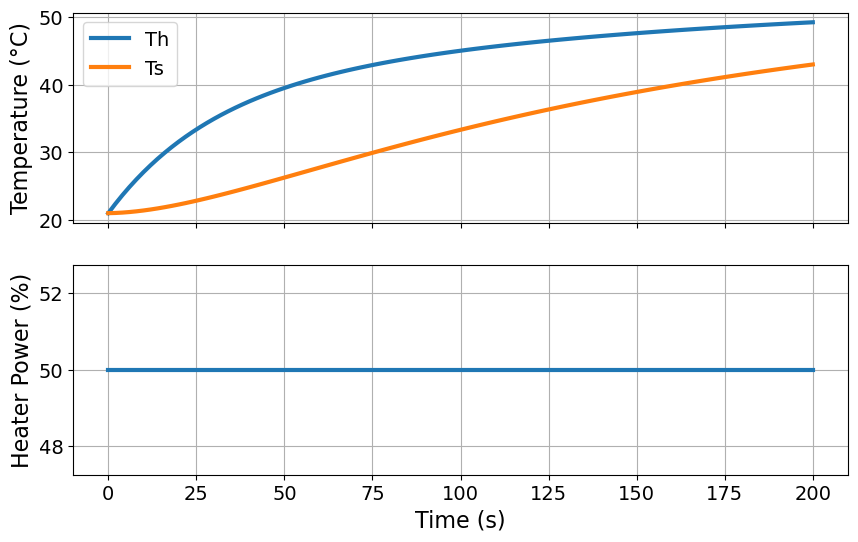

In [3]:
# final time [seconds]
tf = 200

# import Pyomo library
import pyomo.environ as pyo
import pyomo.dae as dae

# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater/Sensor')

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th = pyo.Var(m.t)
m.Ts = pyo.Var(m.t)

# Define the derivatives of the state variables
m.dTh = dae.DerivativeVar(m.Th)
m.dTs = dae.DerivativeVar(m.Ts)

m.u = pyo.Var(m.t, bounds = (0, 100))

# Define the first differential equation
def heater1(m, t):
    return (
        CpH * m.dTh[t]
        == Ua * (Tamb - m.Th[t]) + Ub * (m.Ts[t] - m.Th[t]) + alpha * P * m.u[t]
    )

m.heater1_con = pyo.Constraint(m.t, rule=heater1)


# Define the second differential equation
def sensor1(m, t):
    return CpS * m.dTs[t] == Ub * (m.Th[t] - m.Ts[t])


m.sensor1_con = pyo.Constraint(m.t, rule=sensor1)

# Set the initial conditions
m.Th[0].fix(Tamb)
m.Ts[0].fix(Tamb)

# Apply a finite difference formula to numerically integrate the differential equations
pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=100, wrt=m.t)

for t in m.t:
    m.u[t].fix(50) # control input

# Call our nonlinear optimization/equation solver, Ipopt
pyo.SolverFactory('ipopt').solve(m)

# Plot the results
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Temperature
ax[0].plot(m.t, [m.Th[t]() for t in m.t], label="Th")
ax[0].plot(m.t, [m.Ts[t]() for t in m.t], label="Ts")
ax[0].legend()
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid()

# Plot 2: Heater Power
# ax[1].axhline(u, label="Power")
ax[1].plot(m.t, [m.u[t]() for t in m.t], label="Power")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Heater Power (%)")
ax[1].grid()

In [4]:
'''
m.distance = pyo.Var()

def distance_eq(m, t1, t2):
    if t1 == t2:
        return pyo.Constraint.Skip
    else:
        return m.distance <= (m.Ts[t1] - m.Ts[t2])**2/(60 - 20)**2 + (m.Ts[t1] - m.Ts[t2])**2/(100 - 0)**2

m.distance_con = pyo.Constraint(m.t, m.t, rule=distance_eq)


m.obj = pyo.Objective(expr=m.distance, sense=pyo.maximize)
'''

m.distance = pyo.Var(m.t, bounds=(0, 1))

def distance_eq(m, t1, t2):
    if t1 == t2:
        return pyo.Constraint.Skip
    else:
        # Distance to closest point
        return m.distance[t1] <= (m.Ts[t1] - m.Ts[t2])**2/(70 - 20)**2 + (m.u[t1] - m.u[t2])**2/(100 - 0)**2

m.distance_con = pyo.Constraint(m.t, m.t, rule=distance_eq)

m.obj = pyo.Objective(expr=sum(m.distance[t1] for t1 in m.t), sense=pyo.maximize)

for t in m.t:
    m.u[t].unfix()
    m.u[t].setlb(0)
    m.u[t].setub(100)

pyo.SolverFactory('ipopt').solve(m, tee=True)



Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

This is Ipopt version 3.13.2, running with linear solver ma27.

Number of nonzeros in equality constraint Jacobian...:     1301
Number of nonzeros in inequality constraint Jacobian.:    50300
Number of nonzeros in Lagrangian Hessian.............:    10201

Total number of variables............................:      604
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      402
Total number of ineq

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 10502, 'Number of variables': 604, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 66.79804801940918}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

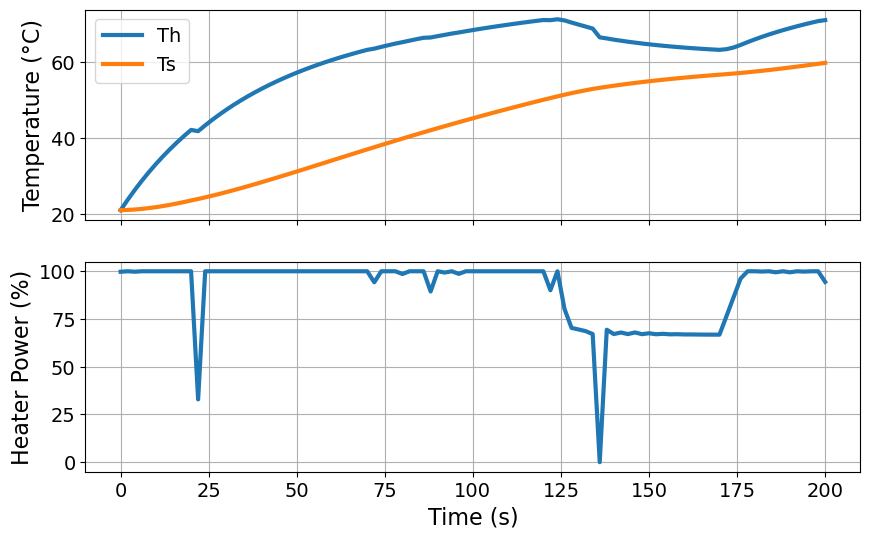

In [5]:
# Plot the results
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Temperature
ax[0].plot(m.t, [m.Th[t]() for t in m.t], label="Th")
ax[0].plot(m.t, [m.Ts[t]() for t in m.t], label="Ts")
ax[0].legend()
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid()

# Plot 2: Heater Power
# ax[1].axhline(u, label="Power")
ax[1].plot(m.t, [m.u[t]() for t in m.t], label="Power")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Heater Power (%)")
ax[1].grid()

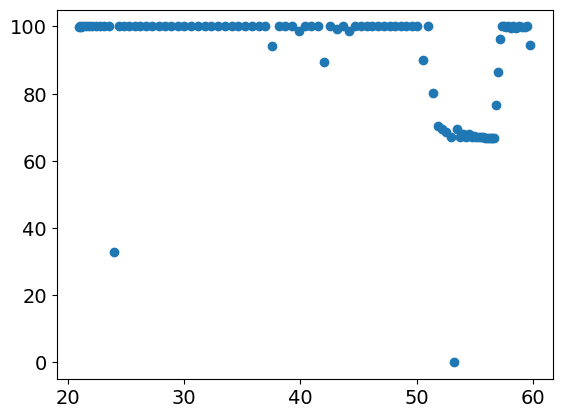

In [6]:
import numpy as np
Ts = np.array([m.Ts[t]() for t in m.t])
u = np.array([m.u[t]() for t in m.t])

plt.scatter(Ts, u)